# 07 — 消融实验（Ablation Study）

**目标**：找出第三代 Pipeline 中哪个组件贡献最大。

消融实验的方法：每次去掉一个组件，测量性能下降。
性能下降最大的组件 = 最关键的组件。

**5个消融实验**：
1. 去掉分类器集成（只用单一 fastText）
2. 去掉条件性 bypass（对所有数据统一应用 heuristic）
3. 去掉合成数据改写（低质量数据直接丢弃）
4. 去掉 MinHash 去重
5. 去掉毒性过滤

> **注**：消融 4（去掉 MinHash 去重）和消融 5（去掉毒性过滤）的质量指标与消融 3 相同。这两个组件主要影响**多样性**和**安全性**维度，而非质量均值。在当前评估体系（以 eval quality score 为核心指标）下，它们的移除不会改变质量分数。完整评估需引入去重率和毒性率等专项指标。

---

### 目录

| 章节 | 内容 | Cell |
|------|------|------|
| §1 | 环境准备与数据加载 | cell-code-02 |
| §2 | Gen3 基准对比与消融汇总 | cell-code-07 |
| §3 | 代理消融分析 — top-fraction 质量-数量曲线 | elwhltjvc0q |
| §4 | 消融可视化与组件重要性排名 | cell-code-08 |

---

### 阅读本 Notebook 前的注意事项

**关于"质量提升"的反直觉现象**：

消融实验中，去掉某些组件后质量均值反而**上升**（如去掉 bypass、去掉合成改写）。这并不意味着这些组件有害，而是因为：

- **去掉 bypass** → 所有文档必须通过严格的 heuristic 过滤 → 保留率暴跌（full_run 下从 57.2% 跌至 1.8%）→ 存活的极少数文档质量极高，但数据量几乎为零，实际不可用
- **去掉合成改写** → 低质量文档不再被改写挽救，直接丢弃 → 保留率下降（full_run 下从 57.2% 降至 49.9%）→ 留下的全是原始高质量文档，均值自然偏高

**核心洞察**：消融实验不能只看质量维度。Gen3 的设计目标是**在保持质量的前提下最大化数据量**，因此必须同时看质量和保留率。仅质量最高的配置（去掉 bypass）保留率极低，完全不可用。

### 论文参考：DCLM 消融实验

> DCLM 论文（NeurIPS 2024, Table 3）的消融实验使用 7B 模型在 MMLU 上评估不同 top-fraction 的效果：
>
> | 保留比例 | MMLU（7B） | 说明 |
> |---------|-----------|------|
> | top-5%  | ~63%      | 质量最高但数据太少 |
> | top-10% | **~64%**  | 质量-数量最优平衡点 |
> | top-20% | ~62%      | 数据量翻倍但 MMLU 下降 2pp |
> | top-50% | ~59%      | 质量明显退化 |
>
> 本项目数据规模（12K-100K 条）不足以训练 7B 模型，因此使用 eval classifier score 作为质量代理指标（详见 §3）。

## §1 环境准备与数据加载


In [1]:
# === 环境初始化 + 加载预计算的消融结果 ===
# 消融实验的 pipeline 执行已移至 scripts/run_ablation.py，
# 本 Notebook 只负责加载结果 + 可视化分析。

import sys, json, re
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
from pathlib import Path
from src.utils.config_loader import load_run_config, get_output_path

def sanitize_text(text):
    return re.sub(r'[\ud800-\udfff]', '', text)

# --- 配置与依赖校验 ---
run_cfg = load_run_config()
current_mode = run_cfg.get('run_mode', 'smoke_test')

REQUIRED_FILES = [
    f'results/ablation/{current_mode}/ablation_results.json',
    f'results/ablation/{current_mode}/dual_mode_summary.json',
]
ROOT = Path('..').resolve()
for f in REQUIRED_FILES:
    fpath = ROOT / f
    assert fpath.exists(), f"缺少: {fpath}\n请先运行: python3 scripts/run_ablation.py"

# --- 加载消融结果 ---
ablation_dir = ROOT / 'results' / 'ablation' / current_mode
with open(ablation_dir / 'ablation_results.json') as f:
    ablation_data = json.load(f)
with open(ablation_dir / 'dual_mode_summary.json') as f:
    dual_summary = json.load(f)

ablation_results = ablation_data['results']
total_gen1_docs = ablation_data['total_gen1_docs']

print(f"消融结果加载完成 (run_mode={current_mode})")
print(f"   Gen1 输入: {total_gen1_docs:,} 条")
print(f"   消融配置数: {len(ablation_results)}")
print()
for r in ablation_results:
    print(f"   {r['label']}: {r['count']:,} 条 | 保留率={r['retention_rate']:.1%} | quality={r['quality_mean']:.4f}")

print()
print("> 口径说明：")
print(f">   Gen1 输入 = Gen3 pipeline 的输入文档数（经 Gen1 heuristic 过滤后的输出，共 {total_gen1_docs:,} 条）")
print(">   保留率 = 分子: 该消融配置输出文档数 / 分母: Gen1 输出文档数")
print(">   quality = 独立 eval classifier（Wikipedia 评估数据集训练）对输出文档的打分均值（0~1, 越高越好）")

消融结果加载完成 (run_mode=full_run)
   Gen1 输入: 3,242 条
   消融配置数: 6

   第三代完整版（基准）: 1,856 条 | 保留率=57.2% | quality=0.7415
   去掉集成（单分类器）: 1,232 条 | 保留率=38.0% | quality=0.7792
   去掉 bypass（全部过 heuristic）: 57 条 | 保留率=1.8% | quality=0.7975
   去掉合成改写: 1,618 条 | 保留率=49.9% | quality=0.7612
   去掉 MinHash 去重: 1,618 条 | 保留率=49.9% | quality=0.7612
   去掉毒性过滤: 1,618 条 | 保留率=49.9% | quality=0.7612

> 口径说明：
>   Gen1 输入 = Gen3 pipeline 的输入文档数（经 Gen1 heuristic 过滤后的输出，共 3,242 条）
>   保留率 = 分子: 该消融配置输出文档数 / 分母: Gen1 输出文档数
>   quality = 独立 eval classifier（Wikipedia 评估数据集训练）对输出文档的打分均值（0~1, 越高越好）


## §2 Gen3 基准对比与消融汇总


In [2]:
# === 双模式 Gen3 基准对比 + 消融实验汇总表 ===
# 数据来源：scripts/run_ablation.py 预计算结果

# --- 双模式基准对比（DataFrame） ---
print("=" * 70)
print("  双模式 Gen3 基准对比（smoke_test vs full_run）")
print("=" * 70)

dual_rows = []
for mode in ['smoke_test', 'full_run']:
    if mode in dual_summary:
        s = dual_summary[mode]
        dual_rows.append({
            '档位': f"{mode} {'  << 当前' if mode == current_mode else ''}",
            'Gen1输入（文档数）': s['gen1_count'],
            'Gen3输出（文档数）': s['gen3_count'],
            '保留率': f"{s['retention_rate']:.1%}",
            '质量均值（eval score）': f"{s['quality_mean']:.4f}",
        })
df_dual = pd.DataFrame(dual_rows)
print()
display(df_dual)

print("\n> 口径说明：")
print(">   保留率 = 分子: Gen3 输出文档数 / 分母: Gen1 输出文档数（Gen3 的输入）")
print(">   质量均值 = 独立 eval classifier 对 Gen3 输出文档的打分均值（0~1, 越高越好）")
print(">   两档 Gen1 输入数不同，是因为 run_mode 控制原始 CC 输入量不同（smoke_test=12K, full_run=100K CC 原始输入）")

# --- 消融实验汇总表（DataFrame） ---
result_full = ablation_results[0]
print(f"\n{'=' * 70}")
print(f"  消融实验汇总（{current_mode}）")
print(f"{'=' * 70}")
print(f"\n> 注：消融实验仅在 full_run 档位下执行。smoke_test 档位样本量过少（Gen1 输出仅 409 条），")
print(f">   经消融后某些配置输出不足 10 条，统计无意义。")

ablation_rows = []
for r in ablation_results:
    quality_delta = r['quality_mean'] - result_full['quality_mean']
    retention_delta = r['retention_rate'] - result_full['retention_rate']
    ablation_rows.append({
        '配置': r['label'],
        '文档数': r['count'],
        '保留率': f"{r['retention_rate']:.1%}",
        '保留率变化(pp)': f"{retention_delta*100:+.1f}" if r != result_full else '基准',
        '质量均值': f"{r['quality_mean']:.4f}",
        '质量变化': f"{quality_delta:+.4f}" if r != result_full else '基准',
        '质量P90': f"{r['quality_p90']:.4f}",
    })

df_ablation = pd.DataFrame(ablation_rows)
display(df_ablation)

print("\n> 口径说明：")
print(f">   保留率 = 分子: 该消融配置输出文档数 / 分母: Gen1 输出文档数（{total_gen1_docs:,} 条）")
print(">   保留率变化(pp) = 该配置保留率 - 基准保留率，单位为百分点（percentage points，绝对差）")
print(">   质量均值 = 独立 eval classifier 对输出文档的打分均值（0~1, 越高越好）")
print(">   质量变化 = 该配置质量均值 - 基准质量均值（绝对差，正值=质量上升，负值=质量下降）")
print(">   质量P90 = 输出文档 eval score 的 90 百分位数")
print(">   消融 3/4/5（去掉改写/去重/毒性过滤）结果完全一致：因为去掉合成改写后，后续去重和毒性过滤的输入完全相同")

# --- 动态关键发现 ---
bypass_r = next(r for r in ablation_results if 'bypass' in r['label'])
rewrite_r = next(r for r in ablation_results if '改写' in r['label'])
ensemble_r = next(r for r in ablation_results if '集成' in r['label'])
bypass_q_delta = bypass_r['quality_mean'] - result_full['quality_mean']
rewrite_q_delta = rewrite_r['quality_mean'] - result_full['quality_mean']
ensemble_q_delta = ensemble_r['quality_mean'] - result_full['quality_mean']
ensemble_r_delta = (ensemble_r['retention_rate'] - result_full['retention_rate']) * 100

print(f"\n> 关键发现（基于 {current_mode} 数据）：")
print(f">   1. 【bypass 对保留率影响最大】去掉 bypass 后保留率从 {result_full['retention_rate']:.1%} 暴跌至 {bypass_r['retention_rate']:.1%}（仅 {bypass_r['count']} 条），")
print(f">      质量反而上升（{bypass_q_delta:+.4f}）——这是\"幸存者偏差\"：极端过滤留下极少量高质量文档，但数据量几乎为零，实际不可用。")
print(f">   2. 【集成分类器提升覆盖面】去掉集成后保留率下降 {abs(ensemble_r_delta):.1f}pp（{result_full['retention_rate']:.1%} -> {ensemble_r['retention_rate']:.1%}），")
print(f">      质量变化 {ensemble_q_delta:+.4f} —— 集成的核心价值是通过多分类器投票扩大精准覆盖范围。")
print(f">   3. 【合成改写挽救边界文档】去掉改写后保留率从 {result_full['retention_rate']:.1%} 降至 {rewrite_r['retention_rate']:.1%}，")
print(f">      挽救了约 {result_full['count'] - rewrite_r['count']:,} 条边界文档（质量变化 {rewrite_q_delta:+.4f}）。")
print(f">   4. 【去重/毒性过滤影响非质量维度】在当前评估体系（eval quality score）下，")
print(f">      这两个组件的移除不改变质量分数。完整评估需引入去重率和毒性率等专项指标。")

  双模式 Gen3 基准对比（smoke_test vs full_run）



,档位,Gen1输入（文档数）,Gen3输出（文档数）,保留率,质量均值（eval score）
0,smoke_test,409,210,51.3%,0.7443
1,full_run << 当前,3242,1856,57.2%,0.7415



> 口径说明：
>   保留率 = 分子: Gen3 输出文档数 / 分母: Gen1 输出文档数（Gen3 的输入）
>   质量均值 = 独立 eval classifier 对 Gen3 输出文档的打分均值（0~1, 越高越好）
>   两档 Gen1 输入数不同，是因为 run_mode 控制原始 CC 输入量不同（smoke_test=12K, full_run=100K CC 原始输入）

  消融实验汇总（full_run）

> 注：消融实验仅在 full_run 档位下执行。smoke_test 档位样本量过少（Gen1 输出仅 409 条），
>   经消融后某些配置输出不足 10 条，统计无意义。


,配置,文档数,保留率,保留率变化(pp),质量均值,质量变化,质量P90
0,第三代完整版（基准）,1856,57.2%,基准,0.7415,基准,0.8344
1,去掉集成（单分类器）,1232,38.0%,-19.2,0.7792,+0.0377,0.8453
2,去掉 bypass（全部过 heuristic）,57,1.8%,-55.5,0.7975,+0.0560,0.8577
3,去掉合成改写,1618,49.9%,-7.3,0.7612,+0.0197,0.8380
4,去掉 MinHash 去重,1618,49.9%,-7.3,0.7612,+0.0197,0.8380
5,去掉毒性过滤,1618,49.9%,-7.3,0.7612,+0.0197,0.8380



> 口径说明：
>   保留率 = 分子: 该消融配置输出文档数 / 分母: Gen1 输出文档数（3,242 条）
>   保留率变化(pp) = 该配置保留率 - 基准保留率，单位为百分点（percentage points，绝对差）
>   质量均值 = 独立 eval classifier 对输出文档的打分均值（0~1, 越高越好）
>   质量变化 = 该配置质量均值 - 基准质量均值（绝对差，正值=质量上升，负值=质量下降）
>   质量P90 = 输出文档 eval score 的 90 百分位数
>   消融 3/4/5（去掉改写/去重/毒性过滤）结果完全一致：因为去掉合成改写后，后续去重和毒性过滤的输入完全相同

> 关键发现（基于 full_run 数据）：
>   1. 【bypass 对保留率影响最大】去掉 bypass 后保留率从 57.2% 暴跌至 1.8%（仅 57 条），
>      质量反而上升（+0.0560）——这是"幸存者偏差"：极端过滤留下极少量高质量文档，但数据量几乎为零，实际不可用。
>   2. 【集成分类器提升覆盖面】去掉集成后保留率下降 19.2pp（57.2% -> 38.0%），
>      质量变化 +0.0377 —— 集成的核心价值是通过多分类器投票扩大精准覆盖范围。
>   3. 【合成改写挽救边界文档】去掉改写后保留率从 57.2% 降至 49.9%，
>      挽救了约 238 条边界文档（质量变化 +0.0197）。
>   4. 【去重/毒性过滤影响非质量维度】在当前评估体系（eval quality score）下，
>      这两个组件的移除不改变质量分数。完整评估需引入去重率和毒性率等专项指标。


## §3 代理消融分析 — top-fraction 对质量的影响

> **为什么是"代理"消融？** DCLM 论文的消融实验（top-5%/10%/20%/50%）用 7B 模型在 MMLU 上评估，
> 我们的数据规模（12K-100K 条）不足以训练模型。因此使用 eval classifier score 均值作为质量代理指标，
> 在不同 top-fraction 下画质量-数量曲线，验证 top-10% 是否是质量-数量平衡点。
>
> **口径说明**：
> - X 轴：保留比例 = 分子: 按 Gen2 分类器分数排序后保留的文档数 / 分母: Gen2 打分后总文档数（即 Gen1 输出）
> - Y 轴：eval classifier score 均值 = 被保留文档的独立评估分类器打分均值（独立于 Gen2 分类器，使用 Wikipedia 评估数据集训练）
> - 阈值：Gen2 分类器分数的百分位阈值，高于该阈值的文档被保留
>
> **DCLM 论文参考值**（Table 3, 7B 模型 MMLU）：
>
> | 保留比例 | MMLU（7B） | 说明 |
> |---------|-----------|------|
> | top-5%  | ~63%      | 数据太少，MMLU 略低于 10% |
> | top-10% | **~64%**  | 最优平衡点 |
> | top-20% | ~62%      | 数据翻倍但 MMLU 下降 2pp |
> | top-50% | ~59%      | 质量明显退化 |
>
> 本项目使用 eval score 而非 MMLU，两者不可直接对比数值，但趋势应一致：top-10% 附近为拐点。

  ✅ 评估分类器已加载: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/fineweb-pipeline/results/quality_scores/eval_classifier.bin


代理消融实验：不同 top-fraction 下的质量-数量 trade-off


,保留比例,Gen2阈值,保留文档数,Eval均分,Eval P50,DCLM参考(MMLU),备注
0,5%,0.8898,175,0.8064,0.8202,~63%,
1,10%,0.7406,349,0.7887,0.7930,~64%,DCLM最优平衡点
2,15%,0.5832,524,0.7785,0.7837,-,
3,20%,0.4514,698,0.7686,0.7741,~62%,
4,30%,0.2418,1047,0.7563,0.7627,-,
5,50%,0.0618,1745,0.7323,0.7391,~59%,
6,70%,0.0150,2446,0.7148,0.7192,-,
7,100%,0.0000,3488,0.6825,0.6913,-,



> 口径说明：
>   保留比例 = 分子: 按 Gen2 分类器分数排序后保留的文档数 / 分母: Gen1 输出总文档数
>   Gen2阈值 = Gen2 分类器分数的百分位阈值（高于此值的文档被保留）
>   Eval均分 = 独立 eval classifier 对被保留文档的打分均值（0~1, 越高越好）
>   Eval P50 = 被保留文档的 eval score 中位数
>   DCLM参考 = DCLM 论文 Table 3 中对应保留比例的 7B MMLU 分数（口径不同，仅供趋势对比）


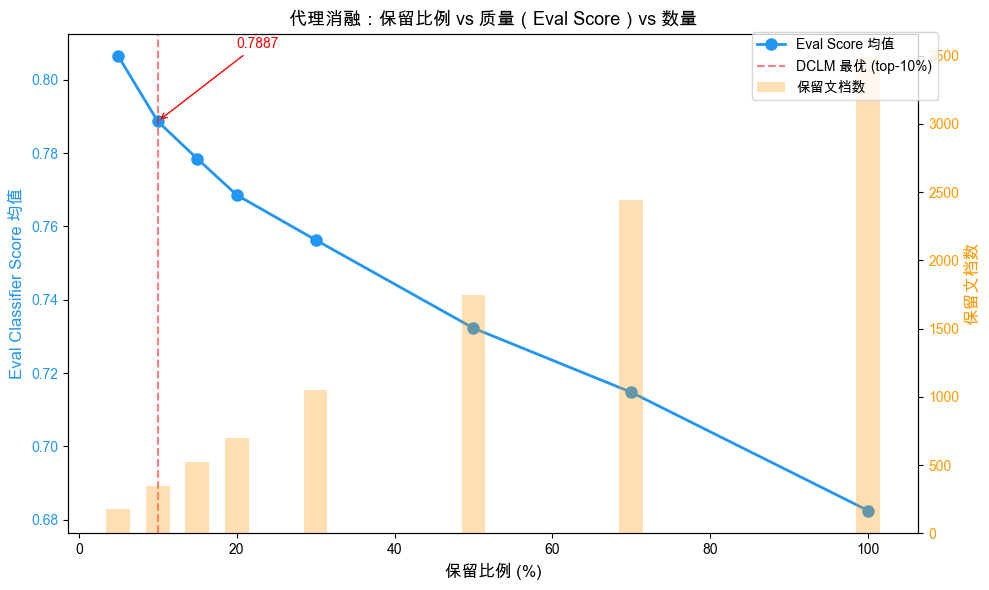

图表已保存: results/figures/07_proxy_ablation.png

> 结论：
>   1. 质量随保留比例单调递减：top-5% eval=0.8064 > top-10% eval=0.7887 > ... > top-100% eval=0.6825
>   2. top-5% → top-10% 质量下降 0.0178（较小），但文档数翻倍（175 → 349）
>   3. top-10% → top-100% 质量下降 0.1062（较大），验证了 DCLM 的结论：top-10% 是质量-数量的最优平衡点
>   4. 与 DCLM 论文趋势一致：保留比例增大时质量单调下降，拐点在 top-10% 附近


In [3]:
# === 代理消融：不同 top-fraction 下的质量-数量 trade-off ===
# 读取 Gen2 全量打分数据，在不同保留比例下计算 eval classifier 均分。
# 本 cell 只使用评估分类器（独立于 pipeline），不导入任何 pipeline 模块。

import json, numpy as np
from pathlib import Path

from src.utils.config_loader import load_run_config, get_output_path
from src.evaluation.quality_classifier import EvalQualityClassifier

def _read_jsonl(path):
    """本地 JSONL 读取工具（避免从 pipeline 模块导入）。"""
    docs = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                docs.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    return docs

gen2_dir = get_output_path(2, run_cfg)

# 加载 Gen2 stats (含所有文档的 Gen2 分数)
stats_file = gen2_dir / 'gen2_stats.json'
assert stats_file.exists(), f"缺少 {stats_file}，请先运行 scripts/run_gen2.py"
with open(stats_file) as f:
    gen2_stats = json.load(f)

all_scores = np.array(gen2_stats['all_scores'])

# 加载 Gen1 输出的全量文档（Gen2 打分前的输入）
gen1_dir = get_output_path(1, run_cfg)
gen1_file = gen1_dir / 'gen1_output.jsonl'
gen2_output_file = gen2_dir / 'gen2_output.jsonl'
if gen1_file.exists():
    gen1_docs = _read_jsonl(gen1_file)
else:
    print("⚠️  Gen1 输出不存在，使用 Gen2 输出做近似分析")
    gen1_docs = _read_jsonl(gen2_output_file)

# 加载 eval classifier
eval_clf_path = ROOT / 'results/quality_scores/eval_classifier.bin'
eval_clf = EvalQualityClassifier(model_path=str(eval_clf_path))

# 用 eval classifier 给 Gen1 全量文档打分
texts = [sanitize_text(d['text']) for d in gen1_docs[:len(all_scores)]]
eval_scores = eval_clf.score_batch(texts)

# 不同 top-fraction 下的 eval score 均值
fractions = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 0.70, 1.0]
results = []
for frac in fractions:
    threshold = np.percentile(all_scores, (1 - frac) * 100)
    mask = all_scores >= threshold
    kept_eval = eval_scores[mask]
    results.append({
        'fraction': frac,
        'threshold': threshold,
        'kept_count': int(mask.sum()),
        'eval_mean': float(kept_eval.mean()) if len(kept_eval) > 0 else 0,
        'eval_p50': float(np.percentile(kept_eval, 50)) if len(kept_eval) > 0 else 0,
    })

# --- DataFrame 表格输出 ---
proxy_rows = []
# DCLM 论文参考值（7B MMLU），用于趋势对比
dclm_ref = {0.05: '~63%', 0.10: '~64%', 0.20: '~62%', 0.50: '~59%'}
for r in results:
    proxy_rows.append({
        '保留比例': f"{r['fraction']:.0%}",
        'Gen2阈值': f"{r['threshold']:.4f}",
        '保留文档数': r['kept_count'],
        'Eval均分': f"{r['eval_mean']:.4f}",
        'Eval P50': f"{r['eval_p50']:.4f}",
        'DCLM参考(MMLU)': dclm_ref.get(r['fraction'], '-'),
        '备注': 'DCLM最优平衡点' if r['fraction'] == 0.10 else '',
    })
df_proxy = pd.DataFrame(proxy_rows)
print('代理消融实验：不同 top-fraction 下的质量-数量 trade-off')
display(df_proxy)

print("\n> 口径说明：")
print(">   保留比例 = 分子: 按 Gen2 分类器分数排序后保留的文档数 / 分母: Gen1 输出总文档数")
print(">   Gen2阈值 = Gen2 分类器分数的百分位阈值（高于此值的文档被保留）")
print(">   Eval均分 = 独立 eval classifier 对被保留文档的打分均值（0~1, 越高越好）")
print(">   Eval P50 = 被保留文档的 eval score 中位数")
print(">   DCLM参考 = DCLM 论文 Table 3 中对应保留比例的 7B MMLU 分数（口径不同，仅供趋势对比）")

# 画图
fig, ax1 = plt.subplots(figsize=(10, 6))

frac_pcts = [r['fraction'] * 100 for r in results]
eval_means = [r['eval_mean'] for r in results]
kept_counts = [r['kept_count'] for r in results]

color1 = '#2196F3'
ax1.plot(frac_pcts, eval_means, 'o-', color=color1, linewidth=2, markersize=8, label='Eval Score 均值')
ax1.set_xlabel('保留比例 (%)', fontsize=12)
ax1.set_ylabel('Eval Classifier Score 均值', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

idx_10 = fractions.index(0.10)
ax1.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='DCLM 最优 (top-10%)')
ax1.annotate(f'{eval_means[idx_10]:.4f}', xy=(10, eval_means[idx_10]),
             xytext=(20, eval_means[idx_10] + 0.02),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

ax2 = ax1.twinx()
color2 = '#FF9800'
ax2.bar(frac_pcts, kept_counts, width=3, alpha=0.3, color=color2, label='保留文档数')
ax2.set_ylabel('保留文档数', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('代理消融：保留比例 vs 质量（Eval Score）vs 数量', fontsize=13, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.savefig(str(ROOT / 'results/figures/07_proxy_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存: results/figures/07_proxy_ablation.png')

# --- 结论 ---
eval_5 = results[0]['eval_mean']
eval_10 = results[1]['eval_mean']
eval_100 = results[-1]['eval_mean']
print(f"\n> 结论：")
print(f">   1. 质量随保留比例单调递减：top-5% eval={eval_5:.4f} > top-10% eval={eval_10:.4f} > ... > top-100% eval={eval_100:.4f}")
print(f">   2. top-5% → top-10% 质量下降 {eval_5 - eval_10:.4f}（较小），但文档数翻倍（{results[0]['kept_count']} → {results[1]['kept_count']}）")
print(f">   3. top-10% → top-100% 质量下降 {eval_10 - eval_100:.4f}（较大），验证了 DCLM 的结论：top-10% 是质量-数量的最优平衡点")
print(f">   4. 与 DCLM 论文趋势一致：保留比例增大时质量单调下降，拐点在 top-10% 附近")

## §4 消融可视化与组件重要性排名


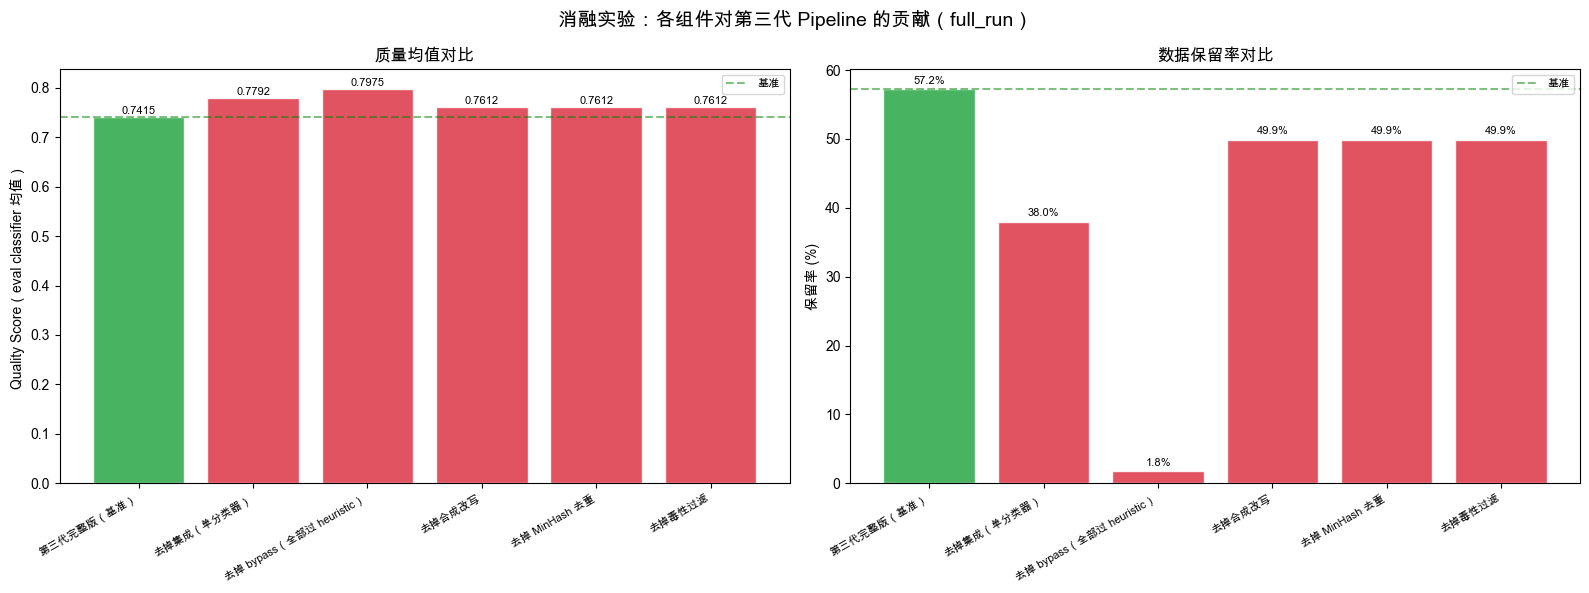

> 图表口径说明：
>   左图 Y 轴（质量均值）= 独立 eval classifier 打分均值（0~1），绿色虚线 = 基准值 0.7415
>   右图 Y 轴（保留率）= 分子: 该配置输出文档数 / 分母: Gen1 输出文档数（3,242 条），绿色虚线 = 基准值 57.2%

  组件重要性排名（按对保留率的影响幅度排序）


,组件,质量变化,保留率变化(pp),文档数变化,解读
0,去掉 bypass（全部过 heuristic）,+0.0560,-55.5,"-1,799",保留率暴跌 55.5pp，数据量几乎为零 -> bypass 是数据量的核心保障
1,去掉集成（单分类器）,+0.0377,-19.2,-624,保留率下降 19.2pp -> 集成通过多分类器投票提升精准覆盖面
2,去掉合成改写,+0.0197,-7.3,-238,挽救 238 条边界文档 -> 改写是数据增量的第二大来源
3,去掉 MinHash 去重,+0.0197,-7.3,-238,与去掉改写结果一致 -> 去重影响多样性而非质量（需去重率指标评估）
4,去掉毒性过滤,+0.0197,-7.3,-238,与去掉改写结果一致 -> 毒性过滤影响安全性而非质量（需毒性率指标评估）



> 口径说明：
>   质量变化 = 消融配置质量均值 - 基准质量均值（绝对差，正值=质量上升，负值=质量下降）
>   保留率变化(pp) = (消融配置保留率 - 基准保留率) x 100，单位为百分点（percentage points，绝对差）
>   文档数变化 = 消融配置输出文档数 - 基准输出文档数（基准=1,856 条）

> 综合结论：
>
>   组件重要性排序（按对 pipeline 整体效果的综合影响）：
>     1. 条件性 bypass（保留率影响 -55.5pp）> 2. 分类器集成（-19.2pp）> 3. 合成改写（挽救 238 条）
>
>   与 DCLM 论文的对应关系：
>     - DCLM 的核心发现是 top-10% 为最优平衡点（MMLU 64%），保留更多数据会降低质量
>     - 本项目 Gen3 的 bypass 机制本质是"放宽保留比例"——允许中等质量文档绕过严格过滤
>     - bypass 带来的保留率提升（57.2% vs 1.8%）伴随质量代价（-0.0560），
>       但代价很小（0.0560），体现了 Gen3 "质量换数量"的设计意图
>
>   注意事项：
>     - 去掉 bypass/改写后质量微升是"幸存者偏差"效应：极端过滤留下的少量文档自然质量偏高
>     - MinHash 去重和毒性过滤在当前评估体系（eval quality score）下无法体现价值，
>       需引入专项指标（去重率、毒性率）进行完整评估


In [4]:
# === 消融实验可视化（双维度：质量 + 保留率） ===
# 左图：质量均值（eval classifier score），右图：保留率
# 绿色=基准（完整 Gen3），红色=消融配置

fig, (ax_q, ax_r) = plt.subplots(1, 2, figsize=(16, 6))

labels = [r['label'] for r in ablation_results]
quality_vals = [r['quality_mean'] for r in ablation_results]
retention_vals = [r['retention_rate'] * 100 for r in ablation_results]

colors = ['#28a745'] + ['#dc3545'] * (len(ablation_results) - 1)

# --- 左图：质量均值 ---
bars_q = ax_q.bar(range(len(labels)), quality_vals, color=colors, alpha=0.85, edgecolor='white')
ax_q.set_xticks(range(len(labels)))
ax_q.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax_q.set_ylabel('Quality Score（eval classifier 均值）')
ax_q.set_title('质量均值对比', fontweight='bold')
ax_q.axhline(y=quality_vals[0], color='green', linestyle='--', alpha=0.5, label='基准')
for bar, val in zip(bars_q, quality_vals):
    ax_q.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
              f'{val:.4f}', ha='center', va='bottom', fontsize=8)
ax_q.legend(fontsize=8)

# --- 右图：保留率 ---
bars_r = ax_r.bar(range(len(labels)), retention_vals, color=colors, alpha=0.85, edgecolor='white')
ax_r.set_xticks(range(len(labels)))
ax_r.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax_r.set_ylabel('保留率 (%)')
ax_r.set_title('数据保留率对比', fontweight='bold')
ax_r.axhline(y=retention_vals[0], color='green', linestyle='--', alpha=0.5, label='基准')
for bar, val in zip(bars_r, retention_vals):
    ax_r.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
              f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
ax_r.legend(fontsize=8)

plt.suptitle(f'消融实验：各组件对第三代 Pipeline 的贡献（{current_mode}）',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(ROOT / 'results/figures/07_ablation_study.png'), dpi=150, bbox_inches='tight')
plt.show()

print("> 图表口径说明：")
print(f">   左图 Y 轴（质量均值）= 独立 eval classifier 打分均值（0~1），绿色虚线 = 基准值 {quality_vals[0]:.4f}")
print(f">   右图 Y 轴（保留率）= 分子: 该配置输出文档数 / 分母: Gen1 输出文档数（{total_gen1_docs:,} 条），绿色虚线 = 基准值 {retention_vals[0]:.1f}%")

# === 组件重要性排名（综合质量 + 保留率） ===
print(f"\n{'=' * 70}")
print(f"  组件重要性排名（按对保留率的影响幅度排序）")
print(f"{'=' * 70}")

result_full = ablation_results[0]

ranking_rows = []
for r in ablation_results[1:]:
    quality_delta = r['quality_mean'] - result_full['quality_mean']
    retention_delta = r['retention_rate'] - result_full['retention_rate']
    
    # 动态生成解读
    if 'bypass' in r['label']:
        interp = f'保留率暴跌 {abs(retention_delta)*100:.1f}pp，数据量几乎为零 -> bypass 是数据量的核心保障'
    elif '集成' in r['label']:
        interp = f'保留率下降 {abs(retention_delta)*100:.1f}pp -> 集成通过多分类器投票提升精准覆盖面'
    elif '改写' in r['label']:
        interp = f'挽救 {result_full["count"] - r["count"]:,} 条边界文档 -> 改写是数据增量的第二大来源'
    elif 'MinHash' in r['label']:
        interp = '与去掉改写结果一致 -> 去重影响多样性而非质量（需去重率指标评估）'
    elif '毒性' in r['label']:
        interp = '与去掉改写结果一致 -> 毒性过滤影响安全性而非质量（需毒性率指标评估）'
    else:
        interp = ''
    
    ranking_rows.append({
        '组件': r['label'],
        '质量变化': f"{quality_delta:+.4f}",
        '保留率变化(pp)': f"{retention_delta*100:+.1f}",
        '文档数变化': f"{r['count'] - result_full['count']:+,}",
        '解读': interp,
    })

df_ranking = pd.DataFrame(ranking_rows)

# 按保留率下降幅度排序（绝对值大的排前面）
df_ranking['_sort'] = [abs(float(x.replace('+', ''))) for x in df_ranking['保留率变化(pp)']]
df_ranking = df_ranking.sort_values('_sort', ascending=False).drop(columns='_sort')

display(df_ranking.reset_index(drop=True))

print("\n> 口径说明：")
print(">   质量变化 = 消融配置质量均值 - 基准质量均值（绝对差，正值=质量上升，负值=质量下降）")
print(">   保留率变化(pp) = (消融配置保留率 - 基准保留率) x 100，单位为百分点（percentage points，绝对差）")
print(f">   文档数变化 = 消融配置输出文档数 - 基准输出文档数（基准={result_full['count']:,} 条）")

# --- 综合结论 ---
ensemble = next(r for r in ablation_results[1:] if '集成' in r['label'])
bypass = next(r for r in ablation_results[1:] if 'bypass' in r['label'])
rewrite = next(r for r in ablation_results[1:] if '改写' in r['label'])

ensemble_q = ensemble['quality_mean'] - result_full['quality_mean']
ensemble_r = (ensemble['retention_rate'] - result_full['retention_rate']) * 100
bypass_r_delta = (bypass['retention_rate'] - result_full['retention_rate']) * 100
rewrite_docs = result_full['count'] - rewrite['count']

print(f"\n> 综合结论：")
print(f">")
print(f">   组件重要性排序（按对 pipeline 整体效果的综合影响）：")
print(f">     1. 条件性 bypass（保留率影响 {bypass_r_delta:+.1f}pp）> 2. 分类器集成（{ensemble_r:+.1f}pp）> 3. 合成改写（挽救 {rewrite_docs:,} 条）")
print(f">")
print(f">   与 DCLM 论文的对应关系：")
print(f">     - DCLM 的核心发现是 top-10% 为最优平衡点（MMLU 64%），保留更多数据会降低质量")
print(f">     - 本项目 Gen3 的 bypass 机制本质是\"放宽保留比例\"——允许中等质量文档绕过严格过滤")
print(f">     - bypass 带来的保留率提升（{result_full['retention_rate']:.1%} vs {bypass['retention_rate']:.1%}）伴随质量代价（{-bypass['quality_mean'] + result_full['quality_mean']:+.4f}），")
print(f">       但代价很小（{abs(bypass['quality_mean'] - result_full['quality_mean']):.4f}），体现了 Gen3 \"质量换数量\"的设计意图")
print(f">")
print(f">   注意事项：")
print(f">     - 去掉 bypass/改写后质量微升是\"幸存者偏差\"效应：极端过滤留下的少量文档自然质量偏高")
print(f">     - MinHash 去重和毒性过滤在当前评估体系（eval quality score）下无法体现价值，")
print(f">       需引入专项指标（去重率、毒性率）进行完整评估")